### 1. Introduction

**Market Basket Analysis** is a data mining technique used to identify relationships between items that frequently appear together in transactions. In this project, I used a synthetic dataset of **1000** student **stationery** purchase transactions, containing items such as **Notebook, Pen, Pencil, Eraser, Sharpener, Highlighter, Geometry Box, Calculator, Sticky Notes, File Folder**. The dataset was created to simulate realistic purchasing behavior without using any personal data.

Basic exploratory data analysis (**EDA**) was performed to understand item frequency and transaction patterns before applying the **Apriori algorithm**. The Apriori algorithm is then used to identify frequent itemsets, and **association rules** are generated using **support, confidence, and lift** to measure the strength of relationships between items. Finally, **scatter** plots such as **support vs. confidence** and **lift vs. confidence** are used to visualize the most meaningful associations between stationery products.

### 2. Importing Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

### 3. Creating the Synthetic Dataset

In [39]:
np.random.seed(42)

items = ['Notebook', 'Pen','Pencil','Eraser', 'Sharpener', 'Highlighter', 'Geometry Box', 'Calculator', 'Sticky Notes', 'File Folder']

transactions = []

for _ in range(1000):

    transaction = []

    # Pattern 1: Notebook buyers often buy Pen
    if np.random.rand() < 0.6:
        transaction.append('Notebook')
        if np.random.rand() < 0.7:
            transaction.append('Pen')

    # Pattern 2: Pencil buyers often buy Eraser and Sharpener
    if np.random.rand() < 0.5:
        transaction.append('Pencil')
        if np.random.rand() < 0.6:
            transaction.append('Eraser')
        if np.random.rand() < 0.5:
            transaction.append('Sharpener')

    # Pattern 3: Geometry Box buyers often buy Calculator
    if np.random.rand() < 0.4:
        transaction.append('Geometry Box')
        if np.random.rand() < 0.5:
            transaction.append('Calculator')

    # Pattern 4: Notebook users often buy Highlighter
    if 'Notebook' in transaction and np.random.rand() < 0.5:
        transaction.append('Highlighter')

    # Independent items
    if np.random.rand() < 0.35:
        transaction.append('Sticky Notes')

    if np.random.rand() < 0.30:
        transaction.append('File Folder')

    if len(transaction) == 0:
        transaction.append(np.random.choice(items))

    transactions.append(transaction)

transactions[:10]

[['Notebook', 'Highlighter', 'Sticky Notes', 'File Folder'],
 ['Sticky Notes'],
 ['Pencil', 'Eraser', 'Sharpener', 'Geometry Box', 'File Folder'],
 ['Pencil', 'Eraser', 'Sharpener', 'File Folder'],
 ['Notebook', 'Pen', 'Pencil', 'Sharpener', 'Geometry Box'],
 ['Notebook',
  'Pen',
  'Pencil',
  'Eraser',
  'Sharpener',
  'Geometry Box',
  'Highlighter'],
 ['Notebook', 'Pen', 'Pencil'],
 ['Notebook',
  'Pen',
  'Pencil',
  'Eraser',
  'Sharpener',
  'Geometry Box',
  'Highlighter',
  'Sticky Notes'],
 ['Notebook', 'Pencil', 'Geometry Box', 'Calculator'],
 ['Pencil', 'Eraser', 'Sharpener']]

### 4. Dataset Description

The dataset used in this project is a synthetic transactional dataset representing purchases of student **stationery items** across **1000** transactions. Each transaction contains a combination of items such as **Notebook, Pen, Pencil, Eraser, Sharpener, Highlighter, Geometry Box, Calculator, Sticky Notes, File Folder**. The dataset was intentionally generated to simulate realistic purchasing patterns by introducing relationships between commonly used stationery items. This structured dataset helps in applying the Apriori algorithm to discover frequent itemsets and meaningful association rules using support, confidence, and lift measures.

### 5. Exploratory Data Analysis (EDA).

In [40]:
from collections import Counter
item_counts = Counter(item for transaction in transactions for item in transaction)
item_counts

Counter({'Notebook': 598,
         'Highlighter': 293,
         'Sticky Notes': 344,
         'File Folder': 317,
         'Pencil': 504,
         'Eraser': 304,
         'Sharpener': 253,
         'Geometry Box': 420,
         'Pen': 424,
         'Calculator': 223})

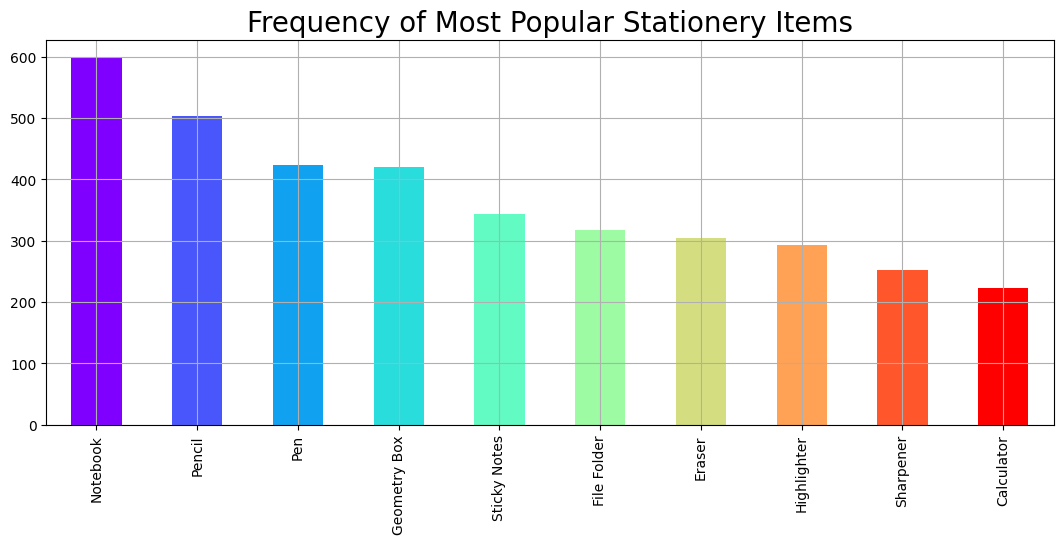

In [41]:
# Most Frequently Purchased Stationery Items

color = plt.cm.rainbow(np.linspace(0, 1, len(item_counts)))

pd.Series(item_counts).sort_values(ascending=False).plot.bar(color=color,  figsize=(13,5))

plt.title('Frequency of Most Popular Stationery Items', fontsize=20)
plt.xticks(rotation=90)
plt.grid()
plt.show()

The bar chart shows the frequency distribution of stationery items across all transactions. It can be observed that notebooks appear most frequently in the dataset, followed by pencils and pens, indicating that these items are commonly purchased together during study sessions. Items such as sharpeners and calculators appear less frequently compared to core writing materials. This distribution helps in understanding item popularity before applying the Apriori algorithm for association rule mining.

### 6. Converting Transactions to One-Hot Encoded Basket

In [42]:
from mlxtend.preprocessing import TransactionEncoder

# Convert transactions into one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

# Display first few rows
df.head()

,Calculator,Eraser,File Folder,Geometry Box,Highlighter,Notebook,Pen,Pencil,Sharpener,Sticky Notes
0,False,False,True,False,True,True,False,False,False,True
1,False,False,False,False,False,False,False,False,False,True
2,False,True,True,True,False,False,False,True,True,False
3,False,True,True,False,False,False,False,True,True,False
4,False,False,False,True,False,True,True,True,True,False


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Calculator    1000 non-null   bool 
 1   Eraser        1000 non-null   bool 
 2   File Folder   1000 non-null   bool 
 3   Geometry Box  1000 non-null   bool 
 4   Highlighter   1000 non-null   bool 
 5   Notebook      1000 non-null   bool 
 6   Pen           1000 non-null   bool 
 7   Pencil        1000 non-null   bool 
 8   Sharpener     1000 non-null   bool 
 9   Sticky Notes  1000 non-null   bool 
dtypes: bool(10)
memory usage: 9.9 KB


### 7. Apriori Algorithm

In [32]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df, min_support=0.03, use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False)

frequent_itemsets.sort_values(by='support', ascending=False).head(10)

,support,itemsets
5,0.598,(Notebook)
7,0.504,(Pencil)
6,0.424,(Pen)
3,0.420,(Geometry Box)
45,0.416,"(Notebook, Pen)"
9,0.344,(Sticky Notes)
2,0.317,(File Folder)
1,0.304,(Eraser)
24,0.301,"(Eraser, Pencil)"
46,0.300,"(Pencil, Notebook)"


The **Apriori algorithm** was applied to identify frequently occurring stationery items and their combinations within the transaction dataset using a **minimum support threshold of 0.03**. The results show that individual items such as **notebooks, pencils, and pens** appear most frequently across transactions. In addition to single items, combinations like notebook and pen also appear together with relatively high support, indicating a strong co-occurrence pattern. These frequent itemsets provide the foundation for generating association rules in the next step of the analysis.

### 8. Generating Association Rules

In [33]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules( frequent_itemsets, metric="lift", min_threshold=1.0 )

selected_columns = ['antecedents','consequents','antecedent support','consequent support','support', 'confidence','lift']

rules_sorted = rules.sort_values(by='lift', ascending=False)

rules_sorted[selected_columns].head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
2555,"(Pencil, Notebook, Calculator)","(Geometry Box, Eraser, Pen)",0.061,0.058,0.030,0.491803,8.479367
2542,"(Geometry Box, Eraser, Pen)","(Pencil, Notebook, Calculator)",0.058,0.061,0.030,0.517241,8.479367
2547,"(Calculator, Eraser, Pen)","(Geometry Box, Pencil, Notebook)",0.030,0.120,0.030,1.000000,8.333333
2550,"(Geometry Box, Pencil, Notebook)","(Calculator, Eraser, Pen)",0.120,0.030,0.030,0.250000,8.333333
2546,"(Calculator, Pencil, Pen)","(Geometry Box, Eraser, Notebook)",0.047,0.077,0.030,0.638298,8.289583
2551,"(Geometry Box, Eraser, Notebook)","(Calculator, Pencil, Pen)",0.077,0.047,0.030,0.389610,8.289583
2541,"(Geometry Box, Pencil, Pen)","(Eraser, Notebook, Calculator)",0.089,0.041,0.030,0.337079,8.221431
2556,"(Eraser, Notebook, Calculator)","(Geometry Box, Pencil, Pen)",0.041,0.089,0.030,0.731707,8.221431
1661,"(Pencil, Notebook, Calculator)","(Geometry Box, Eraser)",0.061,0.127,0.041,0.672131,5.292371
1668,"(Geometry Box, Eraser)","(Pencil, Notebook, Calculator)",0.127,0.061,0.041,0.322835,5.292371


**Association rules** were generated from the frequent itemsets using the lift metric with a **minimum threshold value of 1.0** to identify meaningful relationships between stationery items. The results show several strong associations among items such as **calculators, pencils, notebooks, erasers, pens, and geometry boxes**. These combinations appear together more frequently than expected by chance, as indicated by their **high lift** values. This suggests that these items are commonly purchased together within the same transaction and form important item groups in the dataset.

### 9.1 Scatter Graph (Support vs Confidence)

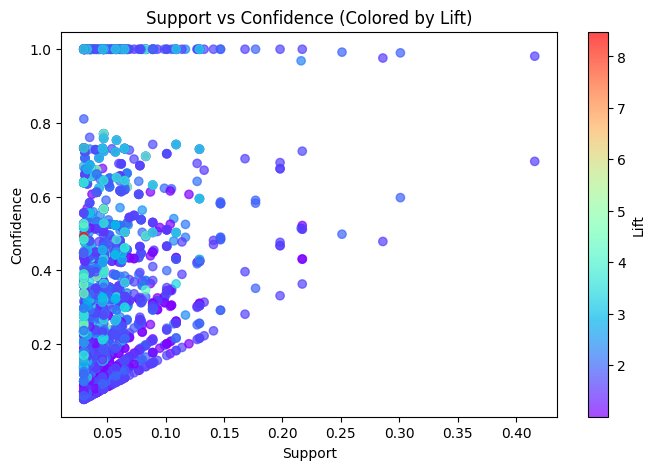

In [34]:
# Scatter graph Support vs Confidence
plt.figure(figsize=(8,5))

scatter = plt.scatter( rules['support'], rules['confidence'], c=rules['lift'], cmap='rainbow', alpha=0.7 )

plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (Colored by Lift)')
plt.show()

The above scatter plot shows the relationship between **support and confidence** for the generated association rules, with **color representing the lift values**. It can be observed that several rules have moderate support but relatively high confidence, indicating reliable item relationships within the transactions. The color variation highlights rules with higher lift values, suggesting stronger associations among certain stationery item combinations. These observations help identify the most meaningful rules before selecting them for further analysis.

### 9.2 Scatter Graph (Lift vs Confidence)

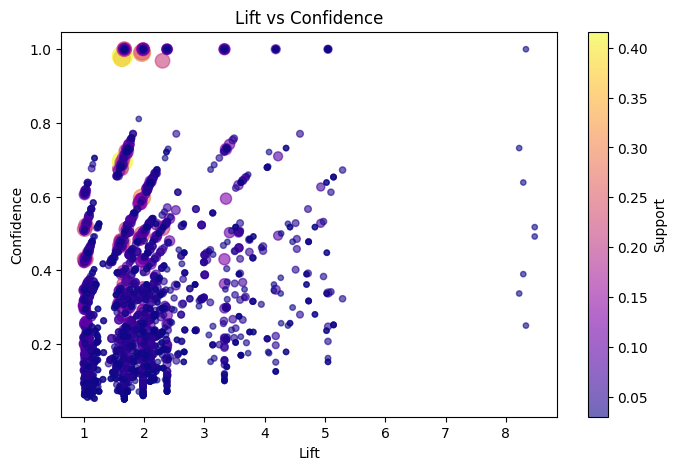

In [35]:
# Scatter graph Lift vs Confidence
plt.figure(figsize=(8,5))

scatter = plt.scatter(rules['lift'], rules['confidence'], s=rules['support']*500, c=rules['support'], cmap='plasma', alpha=0.6)

plt.colorbar(scatter, label='Support')
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.title('Lift vs Confidence')
plt.show()

The above scatter plot shows the relationship between **lift and confidence**. It shows the strength of association rules between stationery items, where color and point size represent support values. Rules with higher lift and confidence indicate stronger relationships between item combinations that occur more frequently than expected by chance. A few rules with relatively high support and confidence can be observed, suggesting important item groups within the dataset that are commonly purchased together.

### 10.1 Top Association Rules Based on Lift

In [36]:
# Display the first few rules with selected columns
selected_columns = ['antecedents', 'consequents', 'confidence', 'lift']
rules_sorted = rules.sort_values(by='lift', ascending=False)
rules_sorted[selected_columns].head()

,antecedents,consequents,confidence,lift
2555,"(Pencil, Notebook, Calculator)","(Geometry Box, Eraser, Pen)",0.491803,8.479367
2542,"(Geometry Box, Eraser, Pen)","(Pencil, Notebook, Calculator)",0.517241,8.479367
2547,"(Calculator, Eraser, Pen)","(Geometry Box, Pencil, Notebook)",1.000000,8.333333
2550,"(Geometry Box, Pencil, Notebook)","(Calculator, Eraser, Pen)",0.250000,8.333333
2546,"(Calculator, Pencil, Pen)","(Geometry Box, Eraser, Notebook)",0.638298,8.289583


### 10.2 Filtering Association Rules

In [37]:
filtered_rules = rules[(rules['support'] >= 0.03) & (rules['confidence'] >= 0.3) & (rules['lift'] >= 1.0)]
far = filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)
far.head()

,antecedents,consequents,support,confidence,lift
2542,"(Geometry Box, Eraser, Pen)","(Pencil, Notebook, Calculator)",0.03,0.517241,8.479367
2555,"(Pencil, Notebook, Calculator)","(Geometry Box, Eraser, Pen)",0.03,0.491803,8.479367
2547,"(Calculator, Eraser, Pen)","(Geometry Box, Pencil, Notebook)",0.03,1.000000,8.333333
2546,"(Calculator, Pencil, Pen)","(Geometry Box, Eraser, Notebook)",0.03,0.638298,8.289583
2551,"(Geometry Box, Eraser, Notebook)","(Calculator, Pencil, Pen)",0.03,0.389610,8.289583


The results show that combinations involving **calculators**, **notebooks**, **pencils**, **erasers**, **pens**, and **geometry boxes** have high lift values, indicating that these items frequently appear together in transactions. Such strong associations suggest that these stationery items form common purchase groups within the dataset.

### 11. Ethical Considerations

**1. What is the source of your dataset (synthetic or UCI ML), and what ethical considerations are associated with it (e.g., consent, privacy)?**

- In this project, I used a **synthetic dataset** representing **stationery items** purchased together by students during academic sessions. <br>
- Since  the dataset was artificially generated for educational purposes, it does not contain any personal or sensitive information. <br>
- Therefore, there are no direct privacy concerns. However, when working with real transactional datasets, it is important to ensure proper consent, remove personal details from the data, and secure handling of customer data.

**2. What potential biases exist in your data or model, and which groups could be affected?**

- The dataset used in this project is synthetic and created with predefined purchasing patterns, it may not fully represent real-world stationery buying behavior. <br>
- The dataset mainly reflects student-type purchases, so it may not capture the needs of other groups such as office users or professionals. As a result, the generated association rules may not be directly applicable to all user groups.


**3. What are the real-world consequences of incorrect predictions (false positives/negatives)?**

- In association rule mining, incorrect predictions may appear as false positives or false negatives. A **false positive** occurs when the model suggests that certain stationery items are strongly related even though they are not actually useful together in practice, which may lead to ineffective product recommendations or store arrangements. <br>
- A **false negative** occurs when meaningful relationships between items are not identified, resulting in missed opportunities to group commonly purchased items such as notebooks, pens, or geometry boxes. <br>
- However, since this project uses a synthetic dataset created for learning purposes, the real-world impact of such errors is limited.

**4. How explainable is your model, and how would you justify its decisions to stakeholders?**

- The **Apriori algorithm** is easy to understand because it generates association rules using measurable values such as support, confidence, and lift. These values clearly show how often stationery items appear together and how strong their relationships are.
- For example, item combinations such as notebooks, pens, and geometry boxes can be interpreted directly from the results. This makes it easier to explain the findings to educators, shop owners, or other stakeholders who want to understand common purchasing patterns.

**5. How could this model be misused, and what safeguards would you suggest?**

- The association rules generated in this project show strong relationships between stationery items such as notebooks, pens, pencils, erasers, calculators, and geometry boxes. In real-world situations, such rules could be misused by encouraging customers to purchase additional items based only on these associations rather than their actual needs.
- For example, grouping several stationery items together in promotions might influence unnecessary purchases.
- To reduce this risk, such models should be used mainly to improve product organization and customer convenience, and not to pressure users into extra buying decisions.

### 12. Conclusion
In this project, **Market Basket Analysis** was performed using the **Apriori algorithm** on a **synthetic dataset** representing **1000 transactions** of student **stationery items** such as **notebooks**, **pens**, **pencils**, **erasers**, **geometry boxes**, **calculators**, and other related materials.

First, a synthetic transactional dataset was created to simulate realistic purchasing behavior between commonly used stationery items. After preparing the dataset in transactional format, the Apriori algorithm was applied to identify frequent itemsets based on a **minimum support = 0.03**. These frequent item combinations helped in understanding which stationery items appear together most often in the transactions.

Next, association rules were generated from the frequent itemsets using support, confidence, and lift measures to evaluate the strength of relationships between items. Several strong associations were observed among combinations such as notebooks, pencils, pens, erasers, calculators, and geometry boxes, indicating that these items are commonly purchased together during study-related purchases.

Further, the generated rules were filtered using minimum thresholds for **support(0.03)**, **confidence(0.3)**, and **lift(1.0)** to retain only meaningful relationships. Scatter plots such as support vs confidence and lift vs confidence were also used to visualize the strength and reliability of these associations.

The results show that combinations involving **calculators, notebooks, pencils, erasers, pens, and geometry boxes** have high lift values, indicating that these items frequently appear together in transactions. Such strong associations suggest that these stationery items form common purchase groups within the dataset.